In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib 

from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import classification_report

ModuleNotFoundError: No module named 'joblib'

In [ ]:
# 1. Chargement des données

df=pd.read_csv(r"data/Bank_transactions.csv", sep=";")

FileNotFoundError: [Errno 2] No such file or directory: 'data/Bank_transactions.csv'

In [ ]:
# 2. Lecture des données
df

,ID Clients,Numero de compte,Identifiant operation,Type de transaction,Status operation,Localisation,Date,Montant,Target
0,1023,851032.0,TR208/1145,Paiement en ligne,Echoué,Kaolack,2025-02-10 22:20:00,45000.0,Normal
1,543,85453.0,TR107/0124,ATM,Echoué,Tambacounda,2025-02-10 17:00:00,18000.0,Suspect
2,1013,851301.0,TR205/00196,Paiement électronique,Validé,Thiès,2025-02-10 03:30:00,200000.0,Normal
3,10360,8501036.0,TR216/00239,ATM,Validé,Kaolack,2025-02-09 09:00:00,29000.0,Normal
4,1022,851202.0,TR208/0023,ATM,Validé,Ziguinchor,2025-02-08 15:55:00,14000.0,Normal
...,...,...,...,...,...,...,...,...,...
5377,1001,851100.0,TR201/00021,Paiement électronique,Validé,Dakar,2024-04-01 10:00:00,1500000.0,Fraude
5378,507,85705.0,TR2/00510027,Paiement en ligne,Validé,Diourbel,2024-02-06 18:00:00,8000.0,Suspect
5379,507,85705.0,TR2/00510045,Paiement en ligne,Validé,Ziguinchor,2024-01-09 15:15:00,80000.0,Fraude
5380,507,85705.0,TR2/00510039,Paiement en ligne,Validé,Kaolack,2024-01-08 13:45:00,40000.0,Suspect


In [ ]:
# 3. Afficher la taille du tableau
df.shape

(5382, 9)

In [ ]:
# 4. afficher l’index
df.index

RangeIndex(start=0, stop=5382, step=1)

In [ ]:
# 5.  identifier les colonnes du fichier
df.columns

Index(['ID Clients', 'Numero de compte', 'Identifiant operation',
       'Type de transaction', 'Status operation', 'Localisation', 'Date',
       'Montant', 'Target'],
      dtype='str')

In [ ]:
#  6.  afficher les 5 premieres lignes du fichier
df.head()

,ID Clients,Numero de compte,Identifiant operation,Type de transaction,Status operation,Localisation,Date,Montant,Target
0,1023,851032.0,TR208/1145,Paiement en ligne,Echoué,Kaolack,2025-02-10 22:20:00,45000.0,Normal
1,543,85453.0,TR107/0124,ATM,Echoué,Tambacounda,2025-02-10 17:00:00,18000.0,Suspect
2,1013,851301.0,TR205/00196,Paiement électronique,Validé,Thiès,2025-02-10 03:30:00,200000.0,Normal
3,10360,8501036.0,TR216/00239,ATM,Validé,Kaolack,2025-02-09 09:00:00,29000.0,Normal
4,1022,851202.0,TR208/0023,ATM,Validé,Ziguinchor,2025-02-08 15:55:00,14000.0,Normal


In [ ]:
 #  7.  afficher les 5 premieres lignes du fichier
df.tail()

,ID Clients,Numero de compte,Identifiant operation,Type de transaction,Status operation,Localisation,Date,Montant,Target
5377,1001,851100.0,TR201/00021,Paiement électronique,Validé,Dakar,2024-04-01 10:00:00,1500000.0,Fraude
5378,507,85705.0,TR2/00510027,Paiement en ligne,Validé,Diourbel,2024-02-06 18:00:00,8000.0,Suspect
5379,507,85705.0,TR2/00510045,Paiement en ligne,Validé,Ziguinchor,2024-01-09 15:15:00,80000.0,Fraude
5380,507,85705.0,TR2/00510039,Paiement en ligne,Validé,Kaolack,2024-01-08 13:45:00,40000.0,Suspect
5381,507,85705.0,TR2/00510033,Paiement en ligne,Validé,Tambacounda,2024-01-07 12:10:00,22000.0,Normal


In [ ]:
# 8.  afficher la structure des données du fichier
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5382 entries, 0 to 5381
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID Clients             5382 non-null   int64  
 1   Numero de compte       5382 non-null   float64
 2   Identifiant operation  5382 non-null   str    
 3   Type de transaction    5382 non-null   str    
 4   Status operation       5382 non-null   str    
 5   Localisation           5382 non-null   str    
 6   Date                   5382 non-null   str    
 7   Montant                5382 non-null   float64
 8   Target                 5382 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 714.1 KB


In [ ]:
# 9.  afficher un resumé des differentes colonnes du fichier
df.describe()

,ID Clients,Numero de compte,Montant
count,5382.000000,5.382000e+03,5.382000e+03
mean,6968.360832,5.724681e+06,2.911279e+05
std,18580.296259,1.824237e+07,1.127725e+06
min,500.000000,8.505100e+04,1.000000e+03
25%,534.000000,8.545100e+04,1.000000e+04
50%,1006.000000,8.510230e+05,4.900000e+04
75%,1038.000000,8.517000e+05,1.500000e+05
max,100300.000000,8.589342e+07,1.500000e+07


In [ ]:
# 10.  afficher le type de données
df.dtypes

ID Clients                 int64
Numero de compte         float64
Identifiant operation        str
Type de transaction          str
Status operation             str
Localisation                 str
Date                         str
Montant                  float64
Target                       str
dtype: object

In [ ]:
# ********QUALITE DES DONNEES********************

# 11.  rechercher les valeurs manquantes
df.isna().sum()

ID Clients               0
Numero de compte         0
Identifiant operation    0
Type de transaction      0
Status operation         0
Localisation             0
Date                     0
Montant                  0
Target                   0
dtype: int64

In [ ]:
# 12.  rechercher les doblons
df.duplicated().sum()

np.int64(0)

In [ ]:
# 13.  Identifier et compter les valeurs categorielles a explorer
for col in ["Type de transaction","Status operation","Target"]:
    print(f"\n{col} :")
    print(df[col].value_counts())



Type de transaction :
Type de transaction
ATM                      1937
Paiement en ligne        1740
Paiement électronique    1705
Name: count, dtype: int64

Status operation :
Status operation
Validé        3612
Echoué         902
En attente     868
Name: count, dtype: int64

Target :
Target
Normal     4093
Suspect    1091
Fraude      198
Name: count, dtype: int64


In [ ]:
# 14.  Identifier certaines villes mal encodées
print("\nVilles :");
print(sorted(df["Localisation"].unique()))



Villes :
['Bakel', 'Bambey', 'Bignona', 'Bounkiling', 'Cap Skirring', 'Dagana', 'Dahra', 'Dakar', 'Diamniadio', 'Diourbel', 'Fatick', 'Foundiougne', 'Gossas', 'Goudiry', 'Goundam', 'Guinguinéo', 'Guédiawaye', 'Hann', 'Kaffrine', 'Kafrine', 'Kanel', 'Kaolack', 'Kebemer', 'Kolda', 'Kédougou', 'Linguère', 'Louga', 'Marie-Therese', 'Matam', 'Mbacké', 'Mbour', 'Nioro', 'Oussouye', 'Pikine', 'Podor', 'Ranérou', 'Richard Toll', 'Rufisque', 'RunÃ©', 'Saint Louis', 'Saint-Louis', 'Saloum', 'Sédhiou', 'Tambacounda', 'Thiès', 'Tivaouane', 'Touba', 'Toubacouta', 'Vélingara', 'Ziguinchor']


In [ ]:
# certaines villes présentent des problèmes d'encodage UTF-8 (ex. "RunÃ©").
#  'Saint Louis' et 'Saint-Louis' sont 02 orthographes differentes pour la meme ville
#  'Kaffrine', 'Kafrine'          sont 02 orthographes differentes pour la meme ville

In [ ]:
df_clean = df.copy()

# 1) Correction des variantes d'orthographe / doublons de villes
correcte_villes = {
    'Saint Louis': 'Saint-Louis',
    'Kafrine': 'Kaffrine',
    'RunÃ©': 'Rufisque',   # probable erreur d'encodage, on la rattache à la catégorie la plus proche
}
df_clean['Localisation'] = df_clean['Localisation'].replace(correcte_villes)

# 2) Regroupement des villes très rares dans une catégorie "Autre"
# But : éviter que le modèle "surapprenne" sur des villes vues 2 ou 3 fois seulement
seuil_min = 15
freq_villes = df_clean['Localisation'].value_counts()
villes_rares = freq_villes[freq_villes < seuil_min].index
df_clean['Localisation'] = df_clean['Localisation'].apply(
    lambda v: 'Autre' if v in villes_rares else v
)

print(f"Nombre de villes avant nettoyage : {df['Localisation'].nunique()}")
print(f"Nombre de catégories après nettoyage : {df_clean['Localisation'].nunique()}")
print()
print(df_clean['Localisation'].value_counts())


Nombre de villes avant nettoyage : 50
Nombre de catégories après nettoyage : 28

Localisation
Dakar           952
Thiès           566
Saint-Louis     560
Tambacounda     492
Kaolack         458
Ziguinchor      435
Kolda           289
Diourbel        279
Matam           169
Autre           134
Louga           132
Fatick          119
Kédougou         85
Kaffrine         83
Bambey           75
Podor            73
Sédhiou          68
Touba            67
Tivaouane        65
Rufisque         59
Richard Toll     57
Mbour            36
Vélingara        28
Pikine           25
Goudiry          22
Dagana           18
Foundiougne      18
Kebemer          18
Name: count, dtype: int64


In [ ]:
# Conversion de la colonne Date en type datetime (elle est actuellement du texte)
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
print(df_clean['Date'].dtype)
print("intervalle de date des transactions :", df_clean['Date'].min(), "->", df_clean['Date'].max())


# tantque la date est un texte on ne peut pas extraire des données temporelles de notre echantillon de données

datetime64[us]
intervalle de date des transactions : 2024-01-07 12:10:00 -> 2025-02-10 22:20:00


In [ ]:
# +++++++++   ANALYSE UNIVARIEE  +++++++++++++++++++++++++++++++++++++++
# observer chaque variable categorielle  une a une afin de comprendre sa distribution globale sans la croiser avec une cible

In [ ]:
# Distribution des 3 classes categorielles du champ TARGET
print(df["Target"].value_counts())
print(df["Target"].value_counts(normalize=True).map("{:.1%}".format))


Target
Normal     4093
Suspect    1091
Fraude      198
Name: count, dtype: int64
Target
Normal     76.0%
Suspect    20.3%
Fraude      3.7%
Name: proportion, dtype: str


In [ ]:
# 76%   = Transactions légitimes 
# 20.3% = Transactions anormal
# 3.7%  = Transactions avec fraudes confirmées 

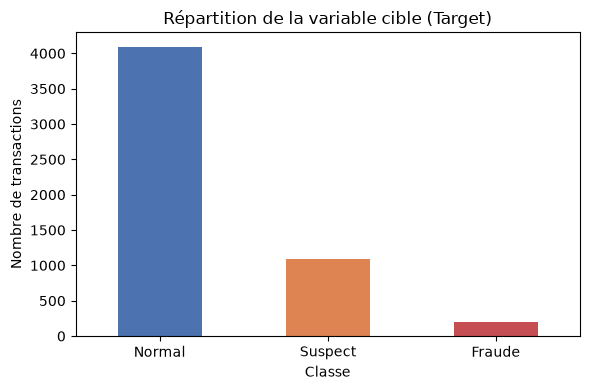

In [ ]:
# visualisation: histogramme variable TARGET
fig, ax = plt.subplots(figsize=(6,4))
df['Target'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452','#C44E52'], ax=ax)
ax.set_title("Répartition de la variable cible (Target)")
ax.set_ylabel("Nombre de transactions")
ax.set_xlabel("Classe")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# traitement des valeurs suspectes et frauduleuses en fonction de leur statut
df["IsFraude"] = df["Target"].isin(["Suspect","Fraude"]).astype(int)
taux_status = df.groupby("Status operation")["IsFraude"] \
                .mean().mul(100).round(1).sort_values(ascending=False)
print("\n=== Taux par Statut ===")
print(taux_status)



=== Taux par Statut ===
Status operation
Echoué        68.8
En attente    37.2
Validé         9.6
Name: IsFraude, dtype: float64


In [ ]:
# Le statut "Echoué" est le prédicteur le plus puissant : 
# 68,8 % des transactions échouées sont Suspectes ou Frauduleuses. 
# Le modèle l'identifiera comme la variable d'importance 

In [ ]:
df["IsFraude"] = df["Target"].isin(["Suspect","Fraude"]).astype(int)
taux_ville = df.groupby("Localisation")["IsFraude"] \
               .mean().mul(100).round(1) \
               .sort_values(ascending=False).head(10)
print("\n=== Top 10 villes ===")
print(taux_ville)



=== Top 10 villes ===
Localisation
Cap Skirring    100.0
Ranérou         100.0
Saint-Louis      71.4
Goundam          66.7
Rufisque         53.7
Dahra            50.0
Podor            49.3
Mbour            41.7
Hann             40.0
Bambey           40.0
Name: IsFraude, dtype: float64


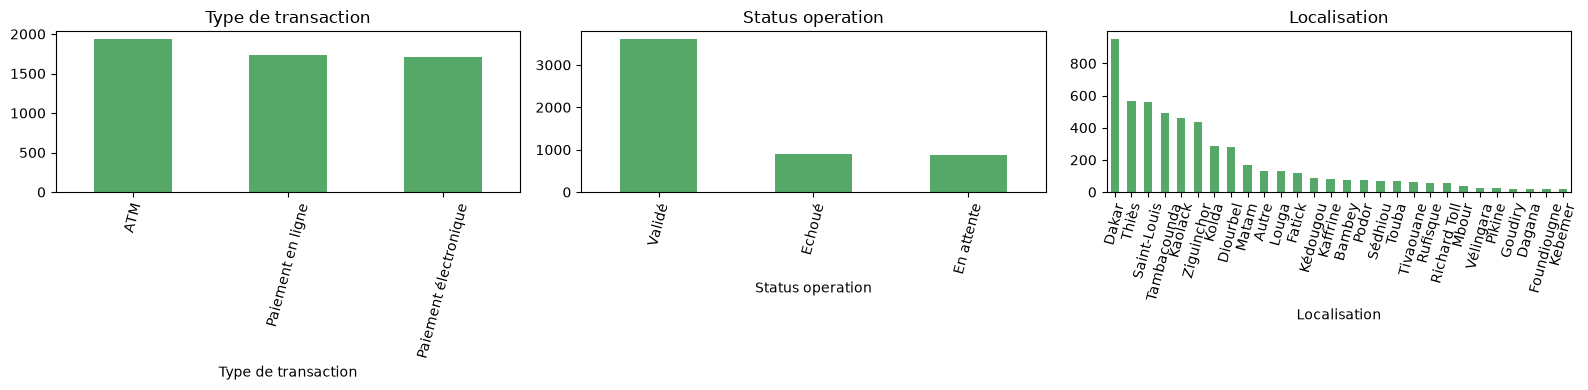

In [ ]:
# graphique de representation des operations en fct du type de transaction, stats operation et leur localisation
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['Type de transaction', 'Status operation', 'Localisation']):
    counts = df_clean[col].value_counts()
    counts.plot(kind='bar', ax=ax, color='#55A868')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()


In [ ]:
# Statistiques descriptives de la variable Montant
df_clean['Montant'].describe()

count    5.382000e+03
mean     2.911279e+05
std      1.127725e+06
min      1.000000e+03
25%      1.000000e+04
50%      4.900000e+04
75%      1.500000e+05
max      1.500000e+07
Name: Montant, dtype: float64

C:\Users\smeno\AppData\Local\Temp\ipykernel_7196\4150180334.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_clean['Montant'], vert=True)


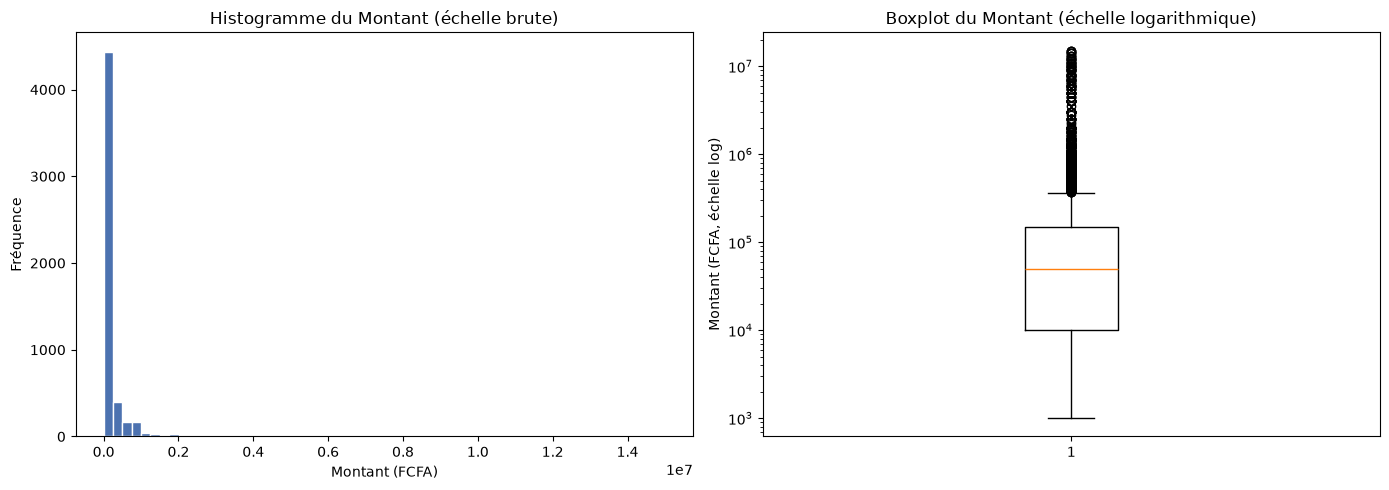

In [ ]:
# Visualisation: histogramme et boxplot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme (échelle log car le Montant est très étalé - quelques très grosses transactions)
axes[0].hist(df_clean['Montant'], bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title("Histogramme du Montant (échelle brute)")
axes[0].set_xlabel("Montant (FCFA)")
axes[0].set_ylabel("Fréquence")

# Boxplot en échelle log pour bien voir les outliers malgré l'étalement
axes[1].boxplot(df_clean['Montant'], vert=True)
axes[1].set_yscale('log')
axes[1].set_title("Boxplot du Montant (échelle logarithmique)")
axes[1].set_ylabel("Montant (FCFA, échelle log)")

plt.tight_layout()
plt.show()



# Boxplot en échelle log pour bien voir les outliers malgré l'étalement

In [ ]:
# Histogramme montre une distribution tres asymetrique(beaucoup de petites transactions 
# et quelques gros montants)
# le boxplot confirme la presence de nombreux outliers au dela de la moustache superieure
# un montant de 10 000 000 FCFA parmi des transactions moyennes à 50 000 FCFA 
# en est un exemple typique.

In [ ]:
# +++++++++++++++++  ANALYSE TEMPORELLE++++++++++++++++++++
df["Date"]        = pd.to_datetime(df["Date"])
df["Heure"]       = df["Date"].dt.hour
df["JourSemaine"] = df["Date"].dt.dayofweek   # 0=Lundi
df["JourMois"]    = df["Date"].dt.day

fraude_heure = df.groupby("Heure")["IsFraude"].mean().mul(100).round(1)
print("Top 5 heures à risque :")
print(fraude_heure.sort_values(ascending=False).head(5))
# Résultat : 6h = 50 %, 8h = 33 %, 16h = 32 %




Top 5 heures à risque :
Heure
6     50.0
8     33.1
16    31.9
17    27.2
13    26.9
Name: IsFraude, dtype: float64


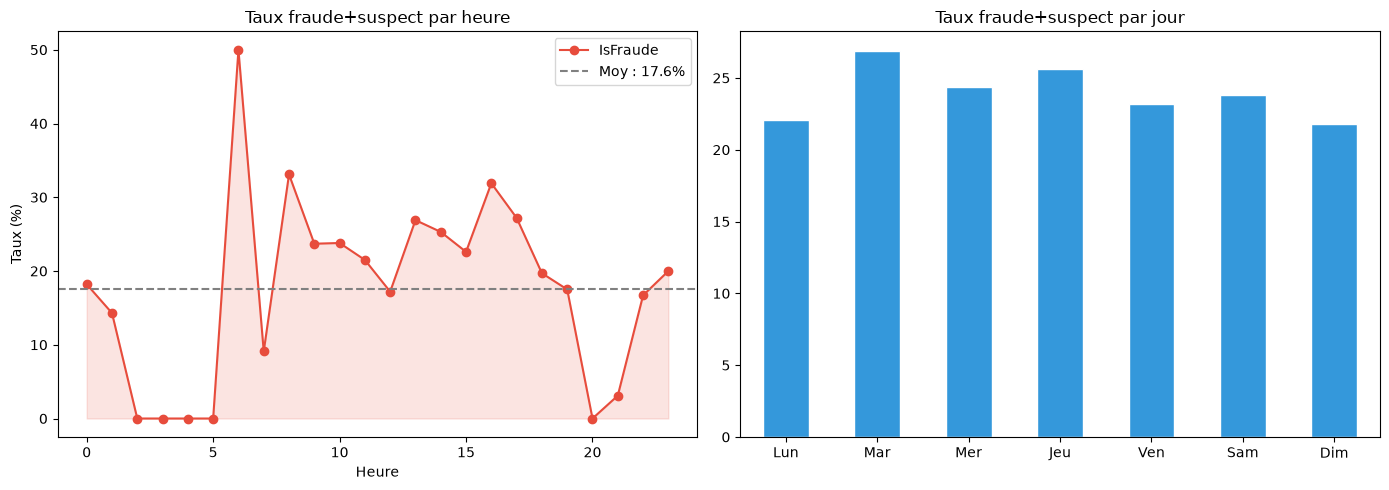

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraude_heure.plot(kind="line", marker="o", color="#E74C3C", ax=axes[0])
axes[0].fill_between(fraude_heure.index, fraude_heure, alpha=0.15, color="#E74C3C")
axes[0].axhline(fraude_heure.mean(), color="gray", linestyle="--",
                label=f"Moy : {fraude_heure.mean():.1f}%")
axes[0].set_title("Taux fraude+suspect par heure")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Taux (%)")
axes[0].legend()

jours = ["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"]
fraude_jour.index = jours[:len(fraude_jour)]
fraude_jour.plot(kind="bar", color="#3498DB", edgecolor="white", ax=axes[1])
axes[1].set_title("Taux fraude+suspect par jour")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
#Pic de fraude à 6h du matin (50 %) et entre 8h-17h. 
#    On créera une feature binaire "Heure_risque" (1 si heure ≥ 22h ou ≤ 8h) pour encoder ce signal 
#        dans le modèle.

In [ ]:
#+++++++++++++++++++    ANALYSE  BIVARIEE +++++++++++++++++++++++++++++
#++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

Target            Fraude  Normal  Suspect
Status operation                         
Echoué              13.7    31.2     55.1
En attente           3.6    62.8     33.6
Validé               1.2    90.4      8.4


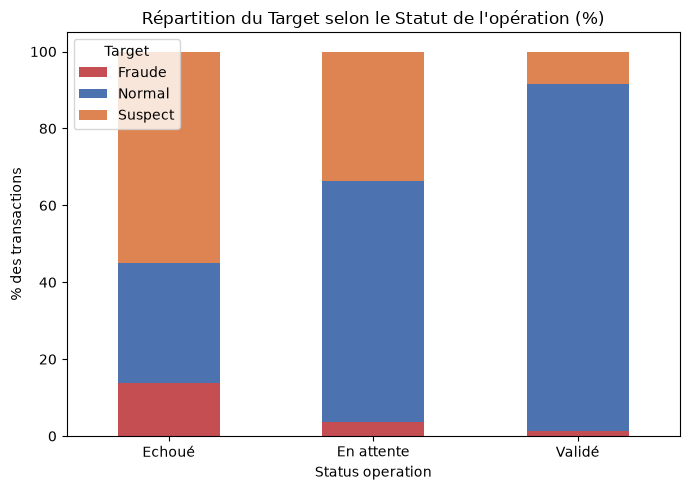

In [ ]:
# ON CROISE CHAQUE VAIABLE EXPLICATIVE AVEC LA CIBLE TARGET POUR IDENTIFIER QUELLE VARIABE DISCRIMINENT LE MIEUX LES FRAUDES
# Statut de l'opération vs Target
ct = pd.crosstab(df_clean['Status operation'], df_clean['Target'], normalize='index') * 100
print(ct.round(1))

ct.plot(kind='bar', stacked=True, figsize=(7,5), color=['#C44E52','#4C72B0','#DD8452'])
plt.title("Répartition du Target selon le Statut de l'opération (%)")
plt.ylabel("% des transactions")
plt.legend(title='Target')
plt.xticks(rotation=0)
plt.tight_layout()

In [ ]:
#les transactions **"Echoué"** contiennent une proportion de Fraude/Suspect largement supérieure à la moyenne (55% de Suspect, 14% de Fraude), 
#contre à peine 1% de fraude pour les transactions "Validé". 
#C'est cohérent avec l'intuition métier : un fraudeur teste souvent des opérations qui échouent (carte volée refusée, tentative de contournement d'un plafond...).

Target                 Fraude  Normal  Suspect
Type de transaction                           
ATM                       1.2    80.8     18.0
Paiement en ligne         2.6    77.6     19.7
Paiement électronique     7.6    69.0     23.5


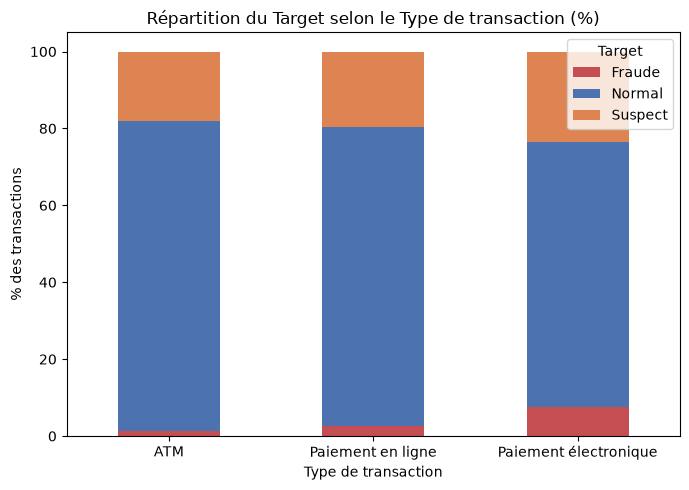

In [ ]:
# Type de transaction vs Target
ct2 = pd.crosstab(df_clean['Type de transaction'], df_clean['Target'], normalize='index') * 100
print(ct2.round(1))

ct2.plot(kind='bar', stacked=True, figsize=(7,5), color=['#C44E52','#4C72B0','#DD8452'])
plt.title("Répartition du Target selon le Type de transaction (%)")
plt.ylabel("% des transactions")
plt.legend(title='Target')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


C:\Users\smeno\AppData\Local\Temp\ipykernel_7196\3647858821.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Target', y='Montant', order=['Normal','Suspect','Fraude'],


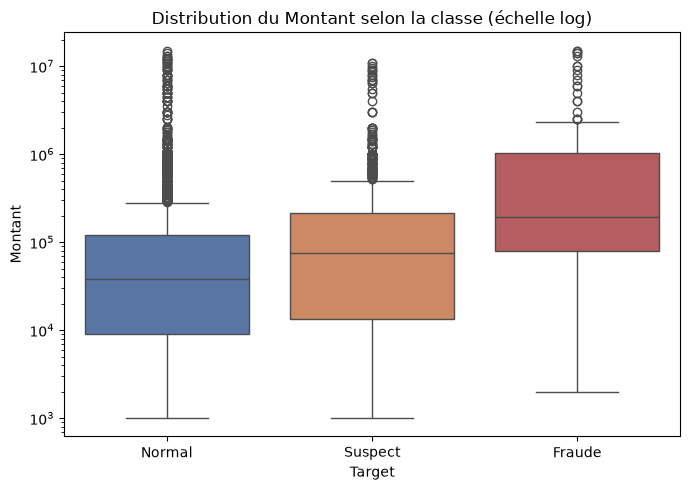

In [ ]:
# Montant vs Target : on utilise ici un boxplot (pas un histogramme) car on compare
# la distribution du Montant ENTRE 3 groupes -> le boxplot est bien plus lisible pour ça
plt.figure(figsize=(7,5))
sns.boxplot(data=df_clean, x='Target', y='Montant', order=['Normal','Suspect','Fraude'],
            palette=['#4C72B0','#DD8452','#C44E52'])
plt.yscale('log')
plt.title("Distribution du Montant selon la classe (échelle log)")
plt.tight_layout()
plt.show()


In [ ]:
#les transactions **Fraude** ont une médiane de montant nettement plus élevée que 
#les transactions Normales — 
#un signal exploitable par le modèle.

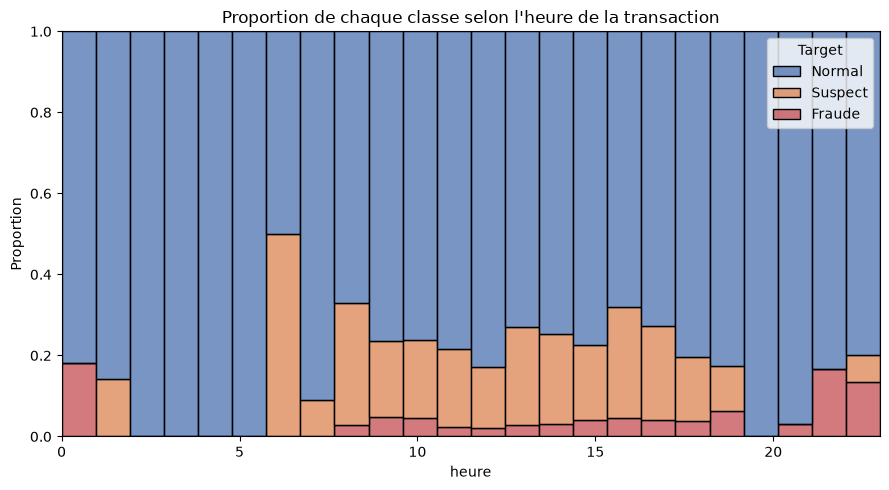

In [ ]:
# Extraction de composantes temporelles pour l'analyse
df_clean['heure'] = df_clean['Date'].dt.hour
df_clean['jour_semaine'] = df_clean['Date'].dt.dayofweek  # 0=lundi ... 6=dimanche
df_clean['est_weekend'] = df_clean['jour_semaine'].isin([5,6]).astype(int)
df_clean['est_nuit'] = df_clean['heure'].apply(lambda h: 1 if (h >= 22 or h <= 5) else 0)

plt.figure(figsize=(9,5))
sns.histplot(data=df_clean, x='heure', hue='Target', hue_order=['Normal','Suspect','Fraude'],
             multiple='fill', bins=24, palette=['#4C72B0','#DD8452','#C44E52'])
plt.title("Proportion de chaque classe selon l'heure de la transaction")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

In [ ]:
# nous allons créer `est_nuit` et `est_weekend` 
# L'heure brute (0 à 23) est une information *cyclique* et granulaire ; 
# un modèle a parfois du mal à en extraire un signal simple. 
# En créant des indicateurs binaires métier ("est-ce la nuit ?", "est-ce le week-end ?"), 
# on **injecte de la connaissance humaine dans les données**

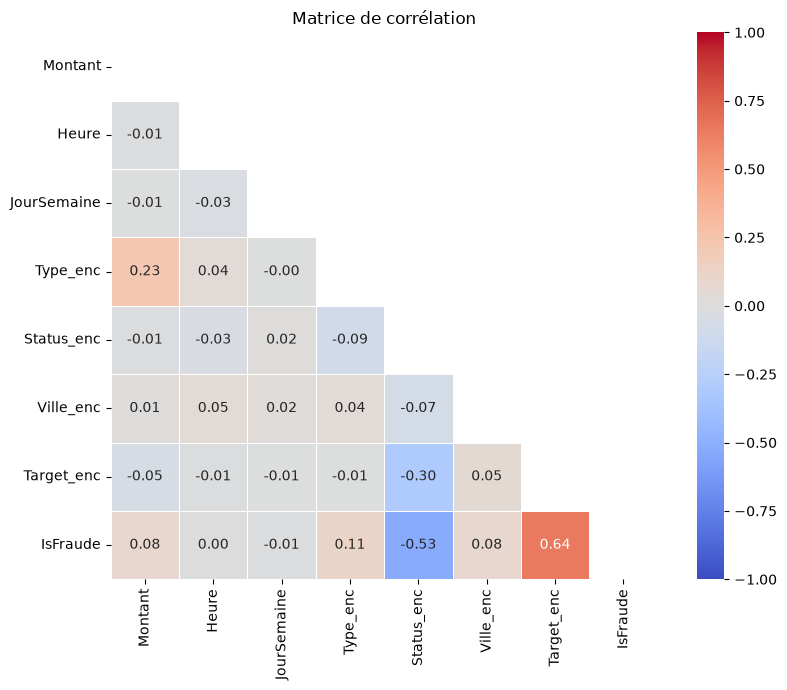

In [ ]:
# matrice de correlation
df_corr = df.copy()
df_corr["Type_enc"]   = LabelEncoder().fit_transform(df["Type de transaction"])
df_corr["Status_enc"] = LabelEncoder().fit_transform(df["Status operation"])
#df_corr["Ville_enc"]  = LabelEncoder().fit_transform(df["Localisation"])
df_corr["Target_enc"] = LabelEncoder().fit_transform(df["Target"])

cols = ["Montant","Heure","JourSemaine","Type_enc",
        "Status_enc","Target_enc","IsFraude"]
# ,"Ville_enc"
corr = df_corr[cols].corr()

plt.figure(figsize=(9,7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5,
            mask=mask, vmin=-1, vmax=1)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.savefig("model/captures/05_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# La  corrélation Status_enc ↔ IsFraude doit être la plus élevée. 
# # Ces observations confirment les deux features les plus importantes pour le modèle.